In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [3]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250122"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_pipipi"
tree_name = "Ks"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [4]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [5]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,380555.000000,380555.000000,380555.000000,380555.000000,380555.000000
mean,1.820698,0.153573,0.401994,1.400836,-0.007481
std,0.106445,0.510125,0.488509,0.891964,0.999973
min,1.600000,-0.998443,-0.904490,0.400002,-1.000000
25%,1.732448,-0.272706,0.061013,0.660095,-1.000000
50%,1.866814,0.213066,0.549442,1.150857,-1.000000
75%,1.873614,0.599531,0.823685,1.939467,1.000000
max,2.100000,0.999999,0.979434,7.483368,1.000000


In [6]:
df_proc13 = df_proc13.query('Dp_M> 1.80 & Dp_M<1.93')


In [7]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,230464.000000,230464.000000,230464.000000,230464.000000,230464.000000
mean,1.868833,0.156023,0.373480,1.542395,-0.005580
std,0.016423,0.508494,0.481668,0.922742,0.999987
min,1.800003,-0.998443,-0.892276,0.400003,-1.000000
25%,1.865584,-0.266630,0.022605,0.767245,-1.000000
50%,1.869995,0.217845,0.499695,1.343279,-1.000000
75%,1.874319,0.599653,0.793161,2.123372,1.000000
max,1.929997,0.999993,0.979434,5.640908,1.000000


In [8]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [18]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250122"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_pipipi"
tree_name = "Ks"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [19]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [20]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.409481e+06,1.409481e+06,1.409481e+06,1.409481e+06,1.409481e+06
mean,1.809310e+00,1.473264e-01,3.932106e-01,1.353573e+00,-2.547746e-03
std,1.108681e-01,5.043281e-01,4.844338e-01,8.615491e-01,9.999971e-01
min,1.600001e+00,-9.987744e-01,-9.075612e-01,4.000016e-01,-1.000000e+00
25%,1.702794e+00,-2.721168e-01,5.294725e-02,6.540379e-01,-1.000000e+00
50%,1.865217e+00,2.025272e-01,5.310167e-01,1.096806e+00,-1.000000e+00
75%,1.872350e+00,5.861095e-01,8.102465e-01,1.854706e+00,1.000000e+00
max,2.099994e+00,9.999989e-01,9.785316e-01,7.787227e+00,1.000000e+00


In [21]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.80 & Dp_M<1.93')


In [22]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,785099.000000,785099.000000,785099.000000,785099.000000,785099.000000
mean,1.868175,0.146330,0.366836,1.523356,-0.002159
std,0.016506,0.505033,0.479151,0.909920,0.999998
min,1.800002,-0.998774,-0.907561,0.400002,-1.000000
25%,1.865431,-0.274038,0.018093,0.763944,-1.000000
50%,1.869625,0.201865,0.487423,1.317968,-1.000000
75%,1.873420,0.585267,0.782649,2.095174,1.000000
max,1.929995,0.999990,0.978532,7.787227,1.000000


In [23]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [24]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [25]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


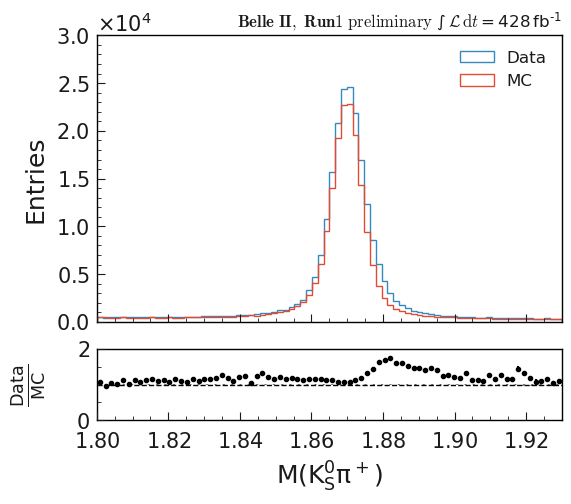

In [27]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.80,1.93)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}.png", bbox_inches="tight")